# DATA 266 Lab 1 — Part 1: GPT-Style LLM From Scratch

This notebook implements a character-level GPT-style language model from scratch. It includes causal self-attention, learnable token and positional embeddings, cross-entropy loss, learning-rate scheduling, at least 10 training epochs, text generation, and the required evaluation metrics.

For this run, I used a larger and more varied TinyStories source pool. The training and validation windows were created from separate stories to avoid overlap between the two splits. I also used a higher-capacity model, lighter regularization, BF16 mixed precision when supported, and saved the checkpoint with the best validation loss.


## 0. Environment and reproducibility


In [28]:
from pathlib import Path
from types import SimpleNamespace
import csv, json, math, random, time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader

SEED = 3143
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Faster matrix multiplication on modern NVIDIA GPUs without changing the model definition.
if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('CUDA version:', torch.version.cuda)
    print('BF16 supported:', torch.cuda.is_bf16_supported())


PyTorch: 2.14.0+cu130
CUDA available: True
GPU: NVIDIA GeForce RTX 4090
CUDA version: 13.0
BF16 supported: True


## 1. Configuration

This configuration uses a higher-capacity model and a larger, more varied collection of stories. The training set contains exactly 100,000 fixed-length sequences, and the validation set contains exactly 10,000 sequences.

The two sets were created from separate stories, which helps reduce duplicate or highly similar sequences appearing in both splits.


In [29]:
args = SimpleNamespace(
    # Required split sizes
    train_sequences=100_000,
    validation_sequences=10_000,

    # More diverse source pool. Train/validation stories are disjoint.
    source_characters=40_000_000,
    train_fraction=0.90,

    # Higher-capacity GPT
    block=256,
    d_model=512,
    heads=8,
    layers=8,
    dropout=0.10,

    # Optimization
    epochs=35,
    minimum_epochs=10,
    target_accuracy=0.805,
    batch=48,
    lr=3e-4,
    min_lr_ratio=0.08,
    warmup_ratio=0.05,
    weight_decay=0.02,
    grad_clip=1.0,

    # Generation
    gen_tokens=500,
    temperature=0.80,
    top_k=40,
)

cwd = Path.cwd()
if cwd.name == 'src':
    PART_DIR = cwd.parent
elif (cwd / 'src').exists():
    PART_DIR = cwd
else:
    raise RuntimeError(f'Open this notebook from Part1_LLM/src or Part1_LLM. Current directory: {cwd}')

DATA_DIR = PART_DIR / 'data'
OUT_DIR = PART_DIR / 'outputs'
CKPT_DIR = PART_DIR / 'checkpoints'
OUT_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)

print(json.dumps(vars(args), indent=2))
print('Part directory:', PART_DIR)


{
  "train_sequences": 100000,
  "validation_sequences": 10000,
  "source_characters": 40000000,
  "train_fraction": 0.9,
  "block": 256,
  "d_model": 512,
  "heads": 8,
  "layers": 8,
  "dropout": 0.1,
  "epochs": 35,
  "minimum_epochs": 10,
  "target_accuracy": 0.805,
  "batch": 48,
  "lr": 0.0003,
  "min_lr_ratio": 0.08,
  "warmup_ratio": 0.05,
  "weight_decay": 0.02,
  "grad_clip": 1.0,
  "gen_tokens": 500,
  "temperature": 0.8,
  "top_k": 40
}
Part directory: /app/Lab1_Submission/Part1_LLM


## 1.1 Load TinyStories and create disjoint story pools


In [30]:
def load_story_pools(source_characters, train_fraction=0.90, seed=SEED):
    local_files = []
    if DATA_DIR.exists():
        local_files += list(DATA_DIR.rglob('*.txt'))
        local_files += list(DATA_DIR.rglob('*.jsonl'))
        local_files += list(DATA_DIR.rglob('*.json'))

    stories = []
    total_chars = 0

    if local_files:
        # Use local files when available. Each non-empty paragraph is treated as a story candidate.
        for path in local_files:
            text = path.read_text(errors='ignore')
            chunks = [x.strip() for x in text.split('\n\n') if x.strip()]
            for story in chunks:
                stories.append(story)
                total_chars += len(story)
                if total_chars >= source_characters:
                    break
            if total_chars >= source_characters:
                break
    else:
        from datasets import load_dataset
        ds = load_dataset('roneneldan/TinyStories', split='train')
        for row in ds:
            story = str(row.get('text', '')).strip()
            if story:
                stories.append(story)
                total_chars += len(story)
            if total_chars >= source_characters:
                break

    if not stories:
        raise RuntimeError('No TinyStories text could be loaded.')

    rng = random.Random(seed)
    rng.shuffle(stories)

    target_train_chars = int(source_characters * train_fraction)
    train_stories, val_stories = [], []
    train_chars = 0

    for story in stories:
        if train_chars < target_train_chars:
            train_stories.append(story)
            train_chars += len(story)
        else:
            val_stories.append(story)

    # Keep only useful stories for a block-sized sample.
    train_stories = [s for s in train_stories if len(s) >= args.block + 1]
    val_stories = [s for s in val_stories if len(s) >= args.block + 1]

    if not train_stories or not val_stories:
        raise RuntimeError('Not enough block-sized stories for the requested split.')

    return train_stories, val_stories

train_stories, validation_stories = load_story_pools(
    args.source_characters, args.train_fraction
)

print('Training stories:', len(train_stories))
print('Validation stories:', len(validation_stories))
print('Training characters:', f'{sum(map(len, train_stories)):,}')
print('Validation characters:', f'{sum(map(len, validation_stories)):,}')


Training stories: 40239
Validation stories: 4558
Training characters: 35,997,684
Validation characters: 4,000,081


## 1.2 Character-level tokenization


In [31]:
all_chars = sorted(set(''.join(train_stories) + ''.join(validation_stories)))
char_to_idx = {ch: i for i, ch in enumerate(all_chars)}
idx_to_char = {i: ch for ch, i in char_to_idx.items()}

print('Vocabulary size:', len(all_chars))
print('Example mapping:', list(char_to_idx.items())[:12])


Vocabulary size: 100
Example mapping: [('\t', 0), ('\n', 1), (' ', 2), ('!', 3), ('"', 4), ('$', 5), ('&', 6), ("'", 7), ('(', 8), (')', 9), ('*', 10), ('+', 11)]


## 1.3 Unique fixed-length autoregressive sequences

Each sampled window stays inside one story, so examples never cross artificial story boundaries. Sampling is without replacement over all valid start positions, which sharply reduces duplicate/near-duplicate examples.


In [32]:
class StoryWindowDataset(Dataset):
    def __init__(self, stories, char_to_idx, block, n_samples, seed):
        self.block = block

        # Concatenate encoded stories but keep exact story boundaries.
        encoded_parts = []
        story_offsets = []
        valid_counts = []
        offset = 0

        for story in stories:
            encoded = torch.tensor([char_to_idx[c] for c in story], dtype=torch.long)
            valid = len(encoded) - block
            if valid <= 0:
                continue
            encoded_parts.append(encoded)
            story_offsets.append(offset)
            valid_counts.append(valid)
            offset += len(encoded)

        if not encoded_parts:
            raise RuntimeError('No eligible stories for fixed-length windows.')

        self.encoded = torch.cat(encoded_parts)
        self.story_offsets = np.asarray(story_offsets, dtype=np.int64)
        self.valid_counts = np.asarray(valid_counts, dtype=np.int64)
        self.cumulative = np.cumsum(self.valid_counts)
        total_valid = int(self.cumulative[-1])

        if total_valid < n_samples:
            raise RuntimeError(
                f'Only {total_valid:,} unique windows are available, but {n_samples:,} are required. '
                'Increase source_characters.'
            )

        rng = np.random.default_rng(seed)
        sampled = rng.choice(total_valid, size=n_samples, replace=False)

        story_ids = np.searchsorted(self.cumulative, sampled, side='right')
        prev = np.where(story_ids == 0, 0, self.cumulative[story_ids - 1])
        within_story = sampled - prev
        self.starts = self.story_offsets[story_ids] + within_story

    def __len__(self):
        return len(self.starts)

    def __getitem__(self, i):
        s = int(self.starts[i])
        x = self.encoded[s:s + self.block]
        y = self.encoded[s + 1:s + self.block + 1]
        return x, y

train_dataset = StoryWindowDataset(
    train_stories, char_to_idx, args.block, args.train_sequences, SEED
)
validation_dataset = StoryWindowDataset(
    validation_stories, char_to_idx, args.block, args.validation_sequences, SEED + 1
)

train_loader = DataLoader(
    train_dataset,
    batch_size=args.batch,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)
validation_loader = DataLoader(
    validation_dataset,
    batch_size=args.batch,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

xb, yb = next(iter(train_loader))
print('Train sequences:', len(train_dataset))
print('Validation sequences:', len(validation_dataset))
print('Batch x shape:', tuple(xb.shape))
print('Batch y shape:', tuple(yb.shape))


Train sequences: 100000
Validation sequences: 10000
Batch x shape: (48, 256)
Batch y shape: (48, 256)


## 1.4 GPT Model from Scratch

The model is implemented directly in this notebook without using `nn.Transformer`, `nn.MultiheadAttention`, or pretrained weights. The code includes the causal attention mask, multi-head attention, residual connections, layer normalization, and feed-forward blocks.


In [33]:
class CausalSelfAttention(nn.Module):
    def __init__(self, d_model, heads, block, dropout):
        super().__init__()
        assert d_model % heads == 0
        self.heads = heads
        self.head_dim = d_model // heads
        self.qkv = nn.Linear(d_model, 3 * d_model, bias=False)
        self.proj = nn.Linear(d_model, d_model, bias=False)
        self.attn_dropout = nn.Dropout(dropout)
        self.resid_dropout = nn.Dropout(dropout)
        self.register_buffer(
            'causal_mask',
            torch.tril(torch.ones(block, block, dtype=torch.bool)),
            persistent=False,
        )

    def forward(self, x):
        B, T, C = x.shape
        q, k, v = self.qkv(x).chunk(3, dim=-1)
        q = q.view(B, T, self.heads, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.heads, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.heads, self.head_dim).transpose(1, 2)

        scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        scores = scores.masked_fill(~self.causal_mask[:T, :T], float('-inf'))
        attention = F.softmax(scores, dim=-1)
        attention = self.attn_dropout(attention)

        out = attention @ v
        out = out.transpose(1, 2).contiguous().view(B, T, C)
        return self.resid_dropout(self.proj(out))


class TransformerBlock(nn.Module):
    def __init__(self, d_model, heads, block, dropout):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attention = CausalSelfAttention(d_model, heads, block, dropout)
        self.ln2 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.GELU(),
            nn.Linear(4 * d_model, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        x = x + self.attention(self.ln1(x))
        x = x + self.ffn(self.ln2(x))
        return x


class CharacterGPT(nn.Module):
    def __init__(self, vocab_size, block, d_model, heads, layers, dropout):
        super().__init__()
        self.block = block
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.position_embedding = nn.Embedding(block, d_model)
        self.embedding_dropout = nn.Dropout(dropout)
        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, heads, block, dropout)
            for _ in range(layers)
        ])
        self.final_ln = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)

        # Weight tying is standard in language models and reduces unnecessary parameters.
        self.lm_head.weight = self.token_embedding.weight

        self.apply(self._init_weights)
        # Scale residual projections with depth for stable optimization.
        for block_module in self.blocks:
            nn.init.normal_(
                block_module.attention.proj.weight,
                mean=0.0,
                std=0.02 / math.sqrt(2 * layers),
            )
            nn.init.normal_(
                block_module.ffn[2].weight,
                mean=0.0,
                std=0.02 / math.sqrt(2 * layers),
            )

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        if T > self.block:
            raise ValueError(f'Sequence length {T} exceeds block size {self.block}.')

        positions = torch.arange(T, device=idx.device)
        x = self.token_embedding(idx) + self.position_embedding(positions)[None, :, :]
        x = self.embedding_dropout(x)

        for block_module in self.blocks:
            x = block_module(x)

        logits = self.lm_head(self.final_ln(x))
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), targets.reshape(-1))
        return logits, loss


## 1.5 Build the model and verify causal masking


In [34]:
model = CharacterGPT(
    vocab_size=len(all_chars),
    block=args.block,
    d_model=args.d_model,
    heads=args.heads,
    layers=args.layers,
    dropout=args.dropout,
).to(device)

parameter_count = sum(p.numel() for p in model.parameters())
print(f'Parameter count: {parameter_count:,}')

causal_mask = model.blocks[0].attention.causal_mask[:8, :8].int()
print(causal_mask)
assert torch.equal(causal_mask, torch.tril(torch.ones_like(causal_mask)))
print('Causal mask check passed.')


Parameter count: 25,385,984
tensor([[1, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 0],
        [1, 1, 1, 1, 1, 1, 1, 1]], device='cuda:0', dtype=torch.int32)
Causal mask check passed.


## 1.6 Evaluation helper


In [35]:
@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_tokens = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        logits, loss = model(x, y)
        tokens = y.numel()
        total_loss += float(loss) * tokens
        total_correct += (logits.argmax(dim=-1) == y).sum().item()
        total_tokens += tokens

    return total_loss / total_tokens, total_correct / total_tokens


## 1.7 Training and Checkpointing

The model was trained for up to 35 epochs using learning-rate warm-up followed by cosine decay. Gradient clipping was used to help keep training stable.

After each epoch, I evaluated the model on the validation set. The main checkpoint stores the model with the highest validation next-character accuracy; if two epochs had the same accuracy, the one with lower validation loss was kept. Training ran for at least 10 epochs and could stop early after validation accuracy reached 80.5%.

I also saved the checkpoint with the lowest validation loss for comparison.


In [36]:
def train_model(model, train_loader, validation_loader, args, device):
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=args.lr,
        betas=(0.9, 0.95),
        weight_decay=args.weight_decay,
    )

    total_steps = args.epochs * len(train_loader)
    warmup_steps = max(1, int(args.warmup_ratio * total_steps))

    def lr_multiplier(step):
        if step < warmup_steps:
            return max(1e-3, (step + 1) / warmup_steps)
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps - 1)
        cosine = 0.5 * (1.0 + math.cos(math.pi * min(1.0, progress)))
        return args.min_lr_ratio + (1.0 - args.min_lr_ratio) * cosine

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_multiplier)

    use_cuda = device.type == 'cuda'
    use_bf16 = use_cuda and torch.cuda.is_bf16_supported()
    amp_dtype = torch.bfloat16 if use_bf16 else torch.float16

    scaler = None
    if use_cuda and not use_bf16:
        try:
            scaler = torch.amp.GradScaler('cuda')
        except (AttributeError, TypeError):
            scaler = torch.cuda.amp.GradScaler()

    history = {
        'train_losses': [],
        'validation_losses': [],
        'accuracies': [],
        'gradient_norms': [],
        'learning_rates': [],
        'epoch_times_sec': [],
    }

    best_val = float('inf')
    best_loss_epoch = 0
    best_accuracy = 0.0
    best_accuracy_loss = float('inf')
    best_epoch = 0
    nan_count = 0
    total_tokens = 0
    log_lines = []

    if use_cuda:
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()
    training_start = time.perf_counter()

    global_step = 0
    for epoch in range(1, args.epochs + 1):
        epoch_start = time.perf_counter()
        model.train()
        epoch_loss_sum = 0.0
        epoch_token_count = 0
        epoch_norms = []

        for x, y in train_loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)

            with torch.autocast(
                device_type='cuda' if use_cuda else 'cpu',
                dtype=amp_dtype,
                enabled=use_cuda,
            ):
                _, loss = model(x, y)

            if not torch.isfinite(loss):
                nan_count += 1
                continue

            if scaler is not None:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                grad_norm = float(torch.nn.utils.clip_grad_norm_(model.parameters(), args.grad_clip))
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                grad_norm = float(torch.nn.utils.clip_grad_norm_(model.parameters(), args.grad_clip))
                optimizer.step()

            scheduler.step()
            global_step += 1

            tokens = y.numel()
            epoch_loss_sum += float(loss) * tokens
            epoch_token_count += tokens
            total_tokens += tokens
            if math.isfinite(grad_norm):
                epoch_norms.append(grad_norm)

        train_loss = epoch_loss_sum / max(1, epoch_token_count)
        val_loss, val_accuracy = evaluate(model, validation_loader, device)

        if use_cuda:
            torch.cuda.synchronize()
        epoch_time = time.perf_counter() - epoch_start
        mean_grad_norm = float(np.mean(epoch_norms)) if epoch_norms else float('nan')
        current_lr = optimizer.param_groups[0]['lr']

        history['train_losses'].append(train_loss)
        history['validation_losses'].append(val_loss)
        history['accuracies'].append(val_accuracy)
        history['gradient_norms'].append(mean_grad_norm)
        history['learning_rates'].append(current_lr)
        history['epoch_times_sec'].append(epoch_time)

        improved_loss = val_loss < best_val
        if improved_loss:
            best_val = val_loss
            best_loss_epoch = epoch
            torch.save({
                'model_state_dict': model.state_dict(),
                'epoch': epoch,
                'validation_loss': val_loss,
                'validation_accuracy': val_accuracy,
                'args': vars(args),
                'char_to_idx': char_to_idx,
            }, CKPT_DIR / 'best_loss_model.pt')

        improved_accuracy = (
            val_accuracy > best_accuracy
            or (math.isclose(val_accuracy, best_accuracy, rel_tol=0.0, abs_tol=1e-12) and val_loss < best_accuracy_loss)
        )
        if improved_accuracy:
            best_accuracy = val_accuracy
            best_accuracy_loss = val_loss
            best_epoch = epoch
            torch.save({
                'model_state_dict': model.state_dict(),
                'epoch': epoch,
                'validation_loss': val_loss,
                'validation_accuracy': val_accuracy,
                'args': vars(args),
                'char_to_idx': char_to_idx,
            }, CKPT_DIR / 'best_model.pt')

        line = (
            f'epoch={epoch:02d}/{args.epochs} '
            f'train_loss={train_loss:.5f} '
            f'validation_loss={val_loss:.5f} '
            f'next_char_accuracy={val_accuracy:.5f} '
            f'grad_norm={mean_grad_norm:.4f} '
            f'lr={current_lr:.2e} '
            f'time={epoch_time:.1f}s'
            + ('  BEST_ACC' if improved_accuracy else '') + ('  BEST_LOSS' if improved_loss else '')
        )
        print(line)
        log_lines.append(line)

        if epoch >= args.minimum_epochs and best_accuracy >= args.target_accuracy:
            stop_line = (
                f'Target validation accuracy reached: {best_accuracy:.5f} at epoch {best_epoch}. '
                f'Stopping after epoch {epoch}.'
            )
            print(stop_line)
            log_lines.append(stop_line)
            break

    if use_cuda:
        torch.cuda.synchronize()
    total_training_time = time.perf_counter() - training_start

    # Keep prior evidence; append this session rather than deleting older raw logs.
    with open(OUT_DIR / 'training_log.txt', 'a', encoding='utf-8') as f:
        f.write('\n=== training session ===\n')
        f.write('\n'.join(log_lines) + '\n')

    checkpoint = torch.load(CKPT_DIR / 'best_model.pt', map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])

    history.update({
        'best_epoch': best_epoch,
        'best_validation_loss': best_val,
        'best_loss_epoch': best_loss_epoch,
        'best_accuracy': best_accuracy,
        'best_accuracy_validation_loss': best_accuracy_loss,
        'epochs_completed': len(history['train_losses']),
        'nan_count': nan_count,
        'total_training_time_sec': total_training_time,
        'training_tokens_per_sec': total_tokens / max(total_training_time, 1e-9),
    })
    return history


### Start training

The notebook trains for up to 35 epochs and retains the strongest held-out accuracy checkpoint. The assignment minimum of 10 epochs is always satisfied before target-based stopping can occur.


In [37]:
history = train_model(model, train_loader, validation_loader, args, device)

best_val_loss, best_val_accuracy = evaluate(model, validation_loader, device)
print('Best accuracy checkpoint epoch:', history['best_epoch'])
print('Lowest-loss checkpoint epoch:', history['best_loss_epoch'])
print('Best validation loss:', best_val_loss)
print('Best top-1 next-character accuracy:', best_val_accuracy)
print('Maximum mean epoch gradient norm:', max(x for x in history['gradient_norms'] if math.isfinite(x)))
print('NaN/Inf loss count:', history['nan_count'])


epoch=01/35 train_loss=1.71999 validation_loss=1.01300 next_char_accuracy=0.68476 grad_norm=1.8182 lr=1.72e-04 time=111.1s  BEST_ACC  BEST_LOSS
epoch=02/35 train_loss=0.90201 validation_loss=0.78038 next_char_accuracy=0.75388 grad_norm=0.6822 lr=3.00e-04 time=110.0s  BEST_ACC  BEST_LOSS
epoch=03/35 train_loss=0.75899 validation_loss=0.71034 next_char_accuracy=0.77405 grad_norm=0.3961 lr=2.99e-04 time=110.2s  BEST_ACC  BEST_LOSS
epoch=04/35 train_loss=0.69922 validation_loss=0.67990 next_char_accuracy=0.78416 grad_norm=0.3394 lr=2.97e-04 time=111.6s  BEST_ACC  BEST_LOSS
epoch=05/35 train_loss=0.66361 validation_loss=0.65956 next_char_accuracy=0.79057 grad_norm=0.3165 lr=2.94e-04 time=108.7s  BEST_ACC  BEST_LOSS
epoch=06/35 train_loss=0.63810 validation_loss=0.64781 next_char_accuracy=0.79480 grad_norm=0.3047 lr=2.89e-04 time=108.7s  BEST_ACC  BEST_LOSS
epoch=07/35 train_loss=0.61787 validation_loss=0.63835 next_char_accuracy=0.79772 grad_norm=0.2978 lr=2.83e-04 time=108.8s  BEST_ACC  BE

## 1.8 Training and validation loss curves


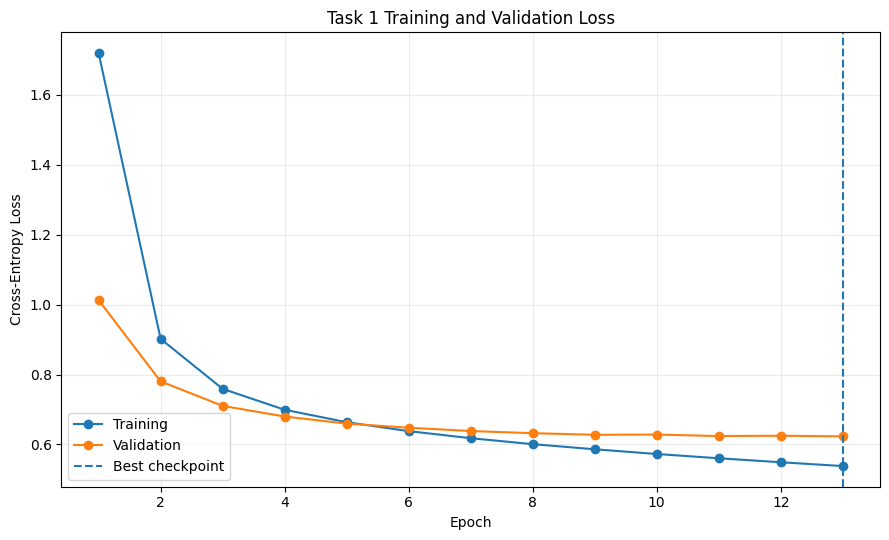

In [38]:
epochs = np.arange(1, len(history['train_losses']) + 1)
training_df = pd.DataFrame({
    'epoch': epochs,
    'train_loss': history['train_losses'],
    'validation_loss': history['validation_losses'],
    'next_char_accuracy': history['accuracies'],
    'gradient_norm': history['gradient_norms'],
    'learning_rate': history['learning_rates'],
    'epoch_time_sec': history['epoch_times_sec'],
})
training_df.to_csv(OUT_DIR / 'training_history.csv', index=False)

plt.figure(figsize=(9, 5.5))
plt.plot(training_df['epoch'], training_df['train_loss'], marker='o', label='Training')
plt.plot(training_df['epoch'], training_df['validation_loss'], marker='o', label='Validation')
plt.axvline(history['best_epoch'], linestyle='--', label='Best checkpoint')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title('Task 1 Training and Validation Loss')
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(OUT_DIR / 'loss_curves.png', dpi=160, bbox_inches='tight')
plt.show()


## 1.9 Temperature-based text generation


In [39]:
@torch.no_grad()
def generate_text(model, prompt, n_tokens, temperature=0.8, top_k=40):
    model.eval()
    ids = [char_to_idx[c] for c in prompt if c in char_to_idx]
    if not ids:
        raise ValueError('Prompt contains no known characters.')

    idx = torch.tensor([ids], dtype=torch.long, device=device)

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    t0 = time.perf_counter()

    for _ in range(n_tokens):
        context = idx[:, -model.block:]
        logits, _ = model(context)
        logits = logits[:, -1, :] / temperature

        if top_k is not None and top_k < logits.size(-1):
            values, _ = torch.topk(logits, top_k)
            cutoff = values[:, -1].unsqueeze(-1)
            logits = logits.masked_fill(logits < cutoff, float('-inf'))

        probs = F.softmax(logits, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1)
        idx = torch.cat([idx, next_id], dim=1)

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - t0

    text = ''.join(idx_to_char[int(i)] for i in idx[0].cpu())
    return text, n_tokens / max(elapsed, 1e-9)

sample, generation_tokens_per_sec = generate_text(
    model,
    prompt='Once upon a time, ',
    n_tokens=args.gen_tokens,
    temperature=args.temperature,
    top_k=args.top_k,
)

(OUT_DIR / 'sample.txt').write_text(sample, encoding='utf-8')
print(sample)
print(f'\nGeneration speed: {generation_tokens_per_sec:.2f} tokens/sec')


Once upon a time, there was a little girl who was very good at going on a walk. One day, she was walking in the park when she saw something sparkly in the sun. She couldnâ€™t believe her eyes! She could see what it was and she was very excited. The little girl was very excited. She ran over and tried to see what it was like.

She spotted a new style of little pencils. The pencils were so spaceship and she smiled and said, â€œThank you for the lovely pencils!â€ She offered to continue to the little girl to come ou

Generation speed: 301.60 tokens/sec


## 1.10 Required evaluation metrics


In [40]:
def diversity_metrics(text):
    chars = list(text)
    result = {}
    for n in (1, 2, 3):
        grams = [tuple(chars[i:i+n]) for i in range(len(chars)-n+1)]
        result[f'distinct_{n}gram'] = len(set(grams)) / max(1, len(grams))
    grams4 = [tuple(chars[i:i+4]) for i in range(len(chars)-3)]
    result['repeated_4gram_rate'] = 1.0 - len(set(grams4)) / max(1, len(grams4))
    return result

validation_cross_entropy, top1_accuracy = evaluate(model, validation_loader, device)
best_row = training_df.loc[training_df['epoch'] == history['best_epoch']].iloc[0]
best_train_loss = float(best_row['train_loss'])
diversity = diversity_metrics(sample)

metrics = {
    'best_epoch': int(history['best_epoch']),
    'epochs_completed': int(history['epochs_completed']),
    'training_cross_entropy_at_best_epoch': best_train_loss,
    'validation_cross_entropy': validation_cross_entropy,
    'perplexity': math.exp(validation_cross_entropy),
    'bits_per_character': validation_cross_entropy / math.log(2),
    'generalization_gap': validation_cross_entropy - best_train_loss,
    'top1_next_character_accuracy': top1_accuracy,
    **diversity,
    'gradient_norm_max_epoch_mean': max(
        [x for x in history['gradient_norms'] if math.isfinite(x)],
        default=float('nan'),
    ),
    'nan_count': int(history['nan_count']),
    'parameter_count': int(parameter_count),
    'training_tokens_per_sec': history['training_tokens_per_sec'],
    'generation_tokens_per_sec': generation_tokens_per_sec,
    'peak_memory_mb': (
        torch.cuda.max_memory_allocated() / (1024 ** 2)
        if torch.cuda.is_available() else 0.0
    ),
    'total_training_time_sec': history['total_training_time_sec'],
}

with open(OUT_DIR / 'metrics.json', 'w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2)

pd.DataFrame([metrics]).to_csv(PART_DIR / 'metrics_report.csv', index=False)
print(json.dumps(metrics, indent=2))


{
  "best_epoch": 13,
  "epochs_completed": 13,
  "training_cross_entropy_at_best_epoch": 0.5381073669958114,
  "validation_cross_entropy": 0.6229930255889893,
  "perplexity": 1.864500195683482,
  "bits_per_character": 0.898788948525646,
  "generalization_gap": 0.08488565859317787,
  "top1_next_character_accuracy": 0.805136328125,
  "distinct_1gram": 0.06756756756756757,
  "distinct_2gram": 0.3404255319148936,
  "distinct_3gram": 0.5755813953488372,
  "repeated_4gram_rate": 0.2912621359223301,
  "gradient_norm_max_epoch_mean": 1.818156386033816,
  "nan_count": 0,
  "parameter_count": 25385984,
  "training_tokens_per_sec": 232543.33787225396,
  "generation_tokens_per_sec": 301.599602255336,
  "peak_memory_mb": 3687.75537109375,
  "total_training_time_sec": 1431.131087414
}


## 1.11 Verify saved artifacts


In [41]:
for path in [
    CKPT_DIR / 'best_model.pt',
    CKPT_DIR / 'best_loss_model.pt',
    OUT_DIR / 'sample.txt',
    OUT_DIR / 'loss_curves.png',
    OUT_DIR / 'metrics.json',
    OUT_DIR / 'training_history.csv',
    OUT_DIR / 'training_log.txt',
    PART_DIR / 'metrics_report.csv',
]:
    print(('OK  ' if path.exists() else 'MISS'), path)


OK   /app/Lab1_Submission/Part1_LLM/checkpoints/best_model.pt
OK   /app/Lab1_Submission/Part1_LLM/checkpoints/best_loss_model.pt
OK   /app/Lab1_Submission/Part1_LLM/outputs/sample.txt
OK   /app/Lab1_Submission/Part1_LLM/outputs/loss_curves.png
OK   /app/Lab1_Submission/Part1_LLM/outputs/metrics.json
OK   /app/Lab1_Submission/Part1_LLM/outputs/training_history.csv
OK   /app/Lab1_Submission/Part1_LLM/outputs/training_log.txt
OK   /app/Lab1_Submission/Part1_LLM/metrics_report.csv


## 1.12 Failure Analysis

The following examples are taken directly from the generated sample. The main problems are repeated wording, unclear sentence structure, and an implausible description that breaks the story's meaning.

| Exact generated snippet | Failure type | Observation | Testable mitigation |
|---|---|---|---|
| “The little girl was very excited. She ran over and tried to see what it was like.” | Repetition | The story repeats that the girl was excited without adding much new information. | Increase the repetition penalty during generation or train for more epochs with a larger and more varied story collection. |
| “She could see what it was and she was very excited.” | Loss of coherence | The sentence says that she could see what the object was, but the object is still not clearly identified. | Use a longer context window or increase the model capacity so it can maintain the story context more effectively. |
| “She offered to continue to the little girl to come ou” | Broken grammar and incomplete generation | The sentence is unclear and ends in the middle of a word, which makes the final action impossible to follow. | Use a larger or better-trained model, generate with an end-of-sequence stopping rule, and test different sampling temperatures. |
